# Final Project Notebook

This notebook is the main running point for the project. It loads the data, explores the features, trains the LSTM and XGBoost models, and compares the results.

In [3]:
import json
import os
import subprocess
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
for candidate in [ROOT, ROOT.parent, ROOT / "..", Path("c:/Users/user/Desktop/School/שנה ד'/סמסטר ב'/אלגוטרייד/algo-trading-lstm-stock-prediction")]:
    candidate = candidate.resolve()
    if (candidate / "train.py").exists() and (candidate / "src").exists():
        ROOT = candidate
        break

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Project root: {ROOT}")

Project root: C:\Users\user\Desktop\School\שנה ד'\סמסטר ב'\אלגוטרייד\algo-trading-lstm-stock-prediction


## Data loading
We load the configured tickers and build a supervised dataset using the project pipeline.

In [4]:
from src.pipeline import build_dataset_for_tickers
from src.data_download import download_price_data

config = {
    "tickers": ["AAPL", "MSFT", "NVDA", "AMZN", "META", "GOOGL", "TSLA", "JPM", "UNH", "XOM"],
    "benchmark_ticker": "SPY",
    "start_date": "2015-01-01",
    "end_date": None,
    "buy_threshold": 0.03,
    "sell_threshold": -0.03,
    "macro_tickers": {"vix": "^VIX", "treasury_10y": "^TNX", "usd_index": "DX-Y.NYB"},
}

full_df, feature_columns = build_dataset_for_tickers(
    tickers=config["tickers"],
    benchmark_ticker=config["benchmark_ticker"],
    start_date=config["start_date"],
    end_date=config["end_date"],
    prediction_horizon=10,
    buy_threshold=config["buy_threshold"],
    sell_threshold=config["sell_threshold"],
    macro_tickers=config["macro_tickers"],
)

print(full_df.head())
print(f"Rows: {len(full_df)}")
print(f"Features: {len(feature_columns)}")
print("Feature columns sample:")
print(feature_columns[:15])

Building dataset for AAPL...
Building dataset for MSFT...
Building dataset for NVDA...
Building dataset for AMZN...
Building dataset for META...
Building dataset for GOOGL...
Building dataset for TSLA...
Building dataset for JPM...
Building dataset for UNH...
Building dataset for XOM...
                 Open       High        Low      Close  Adj Close     Volume  \
Date                                                                           
2015-10-16  27.945000  28.000000  27.632500  27.760000  24.883129  156930400   
2015-10-16  82.260002  82.500000  81.449997  82.480003  52.062065   14304400   
2015-10-16  96.180000  97.589996  95.349998  97.540001  96.690918   25412900   
2015-10-16  28.263500  28.547001  28.015499  28.538000  28.538000   86316000   
2015-10-16  47.020000  47.540001  46.900002  47.509998  41.138531   26450300   

           Ticker  return_1d  log_return_1d  return_5d  ...  \
Date                                                    ...   
2015-10-16   AAPL  -0.007

## EDA
We inspect the target distribution and a couple of return-based features.

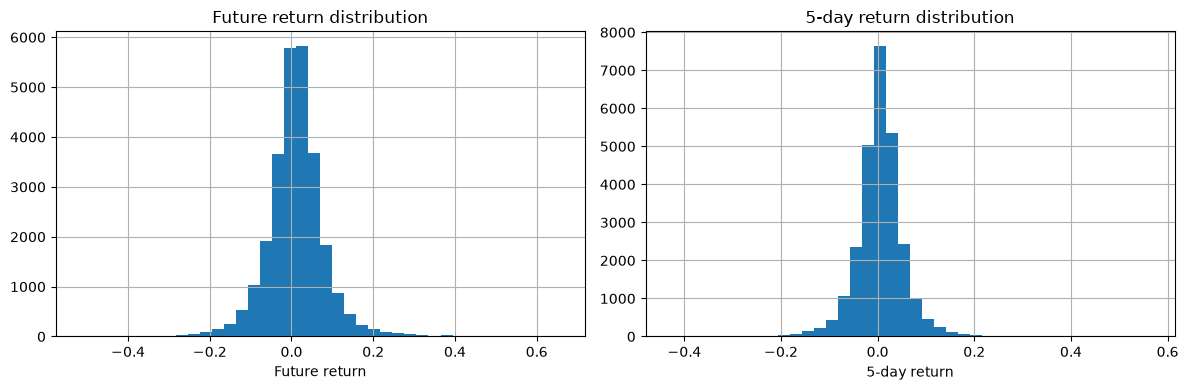

{1: 11484, 2: 9424, 0: 5935}


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
full_df["future_return"].hist(bins=40, ax=axes[0])
axes[0].set_title("Future return distribution")
axes[0].set_xlabel("Future return")

full_df["return_5d"].hist(bins=40, ax=axes[1])
axes[1].set_title("5-day return distribution")
axes[1].set_xlabel("5-day return")
plt.tight_layout()
plt.show()

print(full_df["signal_label"].value_counts().to_dict())

## Feature engineering
The pipeline already adds technical indicators, benchmark features, macro features, and earnings features.

In [6]:
feature_summary = pd.DataFrame({
    "feature": feature_columns,
    "dtype": [str(full_df[col].dtype) for col in feature_columns],
})
print(feature_summary.head(20))

             feature    dtype
0          return_1d  float64
1      log_return_1d  float64
2          return_5d  float64
3         return_10d  float64
4         return_20d  float64
5         return_60d  float64
6             sma_20  float64
7             ema_20  float64
8    price_to_sma_20  float64
9             sma_50  float64
10            ema_50  float64
11   price_to_sma_50  float64
12           sma_200  float64
13           ema_200  float64
14  price_to_sma_200  float64
15   sma_20_above_50  float64
16  sma_50_above_200  float64
17   sma_20_50_cross  float64
18  sma_50_200_cross  float64
19            rsi_14  float64


## LSTM training
Run the existing training script for the selected horizon.

In [7]:
subprocess.run([sys.executable, str(ROOT / "train.py"), "--horizon", "10"], cwd=ROOT, check=True)
print("LSTM training complete")

LSTM training complete


## XGBoost training
Run the XGBoost training script for the same horizon.

In [8]:
subprocess.run([sys.executable, str(ROOT / "train_xgboost.py"), "--horizon", "10"], cwd=ROOT, check=True)
print("XGBoost training complete")

XGBoost training complete


## Model comparison
Compare the saved LSTM and XGBoost metrics.

In [9]:
subprocess.run([sys.executable, str(ROOT / "compare_results.py"), "--horizon", "10"], cwd=ROOT, check=True)
comparison_path = ROOT / "reports" / "model_comparison_h10.csv"
if comparison_path.exists():
    comparison_df = pd.read_csv(comparison_path)
    print(comparison_df)
else:
    print(f"Comparison report not found at {comparison_path}")

     model  accuracy  return_mae  total_return  buy_and_hold_total_return  \
0     LSTM  0.298861    0.056711      0.000000                   7.642285   
1  XGBoost  0.321899    0.066430      1.591668                  11.739569   

   excess_return_vs_buy_hold  max_drawdown  sharpe_ratio  sortino_ratio  \
0                  -7.642285      0.000000      0.000000       0.000000   
1                 -10.147901     -0.552488      2.256489       2.427571   

   win_rate  average_trade_return  number_of_active_trades  \
0  0.000000              0.000000                        0   
1  0.596341              0.012574                      820   

   trade_activation_rate  feature_count  
0               0.000000             58  
1               0.203828             58  


## Backtest comparison
Inspect the backtest outputs and the saved evaluation metrics.

In [10]:
lstm_metrics_path = ROOT / "reports" / "metrics_h10.json"
xgb_metrics_path = ROOT / "reports" / "metrics_xgboost_h10.json"

if lstm_metrics_path.exists() and xgb_metrics_path.exists():
    lstm_metrics = json.loads(lstm_metrics_path.read_text(encoding="utf-8"))
    xgb_metrics = json.loads(xgb_metrics_path.read_text(encoding="utf-8"))

    print("LSTM backtest metrics")
    print(lstm_metrics.get("backtest_metrics", {}))
    print("\nXGBoost backtest metrics")
    print(xgb_metrics.get("backtest_metrics", {}))
else:
    print("One or more metrics files are not available yet. Run the training cells first.")

LSTM backtest metrics
{'initial_cash': 10000.0, 'final_equity': 10000.0, 'total_return': 0.0, 'buy_and_hold_total_return': 7.642284702212647, 'excess_return_vs_buy_hold': -7.642284702212647, 'max_drawdown': 0.0, 'sharpe_ratio': 0.0, 'sortino_ratio': 0.0, 'average_period_return': 0.0, 'period_return_volatility': 0.0, 'number_of_prediction_dates': 343, 'number_of_active_trades': 0, 'trade_activation_rate': 0.0, 'win_rate': 0.0, 'average_trade_return': 0.0, 'best_period_return': 0.0, 'worst_period_return': 0.0}

XGBoost backtest metrics
{'initial_cash': 10000.0, 'final_equity': 25916.67689540328, 'total_return': 1.5916676895403281, 'buy_and_hold_total_return': 11.739569062711253, 'excess_return_vs_buy_hold': -10.147901373170924, 'max_drawdown': -0.5524881096091192, 'sharpe_ratio': 2.256489246623132, 'sortino_ratio': 2.427571219947144, 'average_period_return': 0.0025218152532496528, 'period_return_volatility': 0.017741088788788613, 'number_of_prediction_dates': 403, 'number_of_active_trade

## Risks and future work
The project is an academic simulation. Future improvements can include more robust data sources, regime-aware models, and better transaction-cost modeling.